# R11 Flight：EEG、Force 与 Event 对齐

使用两端共同记录的 BCI2000 `SourceTime` 时钟，将 256 Hz 握力数据和任务事件映射到 2000 Hz EEG 采样轴。

## Setup

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from read_bci2000 import BCI2000Dat
from align_flight_eeg import align_force_to_eeg, flight_event_table

data_dir = Path.cwd()
eeg = BCI2000Dat(data_dir / "testS001R11.dat")
task = BCI2000Dat(data_dir / "testS001R11_1.dat")

## Align

将连续握力插值到 EEG 时间轴，并把任务事件映射为 EEG 样本编号。



In [20]:
eeg_clock_ms, task_clock_ms, force_at_eeg_rate = align_force_to_eeg(eeg, task)
events = pd.DataFrame(flight_event_table(eeg, task, eeg_clock_ms, task_clock_ms))
events

'''
events:

0 Idle
  ↓ OnTrialBegin
1 Countdown
  ↓ OnFeedbackBegin
2 Playing
  ├─ 到达地图终点 → 4 TrialSuccess
  └─ 碰撞/飞出边界 → 3 Hit → 5 TrialFailure
                         ↓
                    6 InterTrial
                         ↓ 下一个 Trial
                    1 Countdown

Run 结束 → 7 SessionComplete
'''

'\nevents:\n\n0 Idle\n  ↓ OnTrialBegin\n1 Countdown\n  ↓ OnFeedbackBegin\n2 Playing\n  ├─ 到达地图终点 → 4 TrialSuccess\n  └─ 碰撞/飞出边界 → 3 Hit → 5 TrialFailure\n                         ↓\n                    6 InterTrial\n                         ↓ 下一个 Trial\n                    1 Countdown\n\nRun 结束 → 7 SessionComplete\n'

### 对齐精度检查

In [21]:
print("最大事件对齐误差 (ms):", events.alignment_error_ms.abs().max())
print("EEG 有效对齐握力点数:", np.isfinite(force_at_eeg_rate).sum(), "/", eeg.samples)
assert events.alignment_error_ms.abs().max() < 0.5

最大事件对齐误差 (ms): 0.18000000000029104
EEG 有效对齐握力点数: 133957 / 134200


## Plot 20 aligned EEG channels, force, and events

选择前 20 个非空通道，逐通道标准化后纵向堆叠显示。标准化只用于可视化，不修改原始信号。

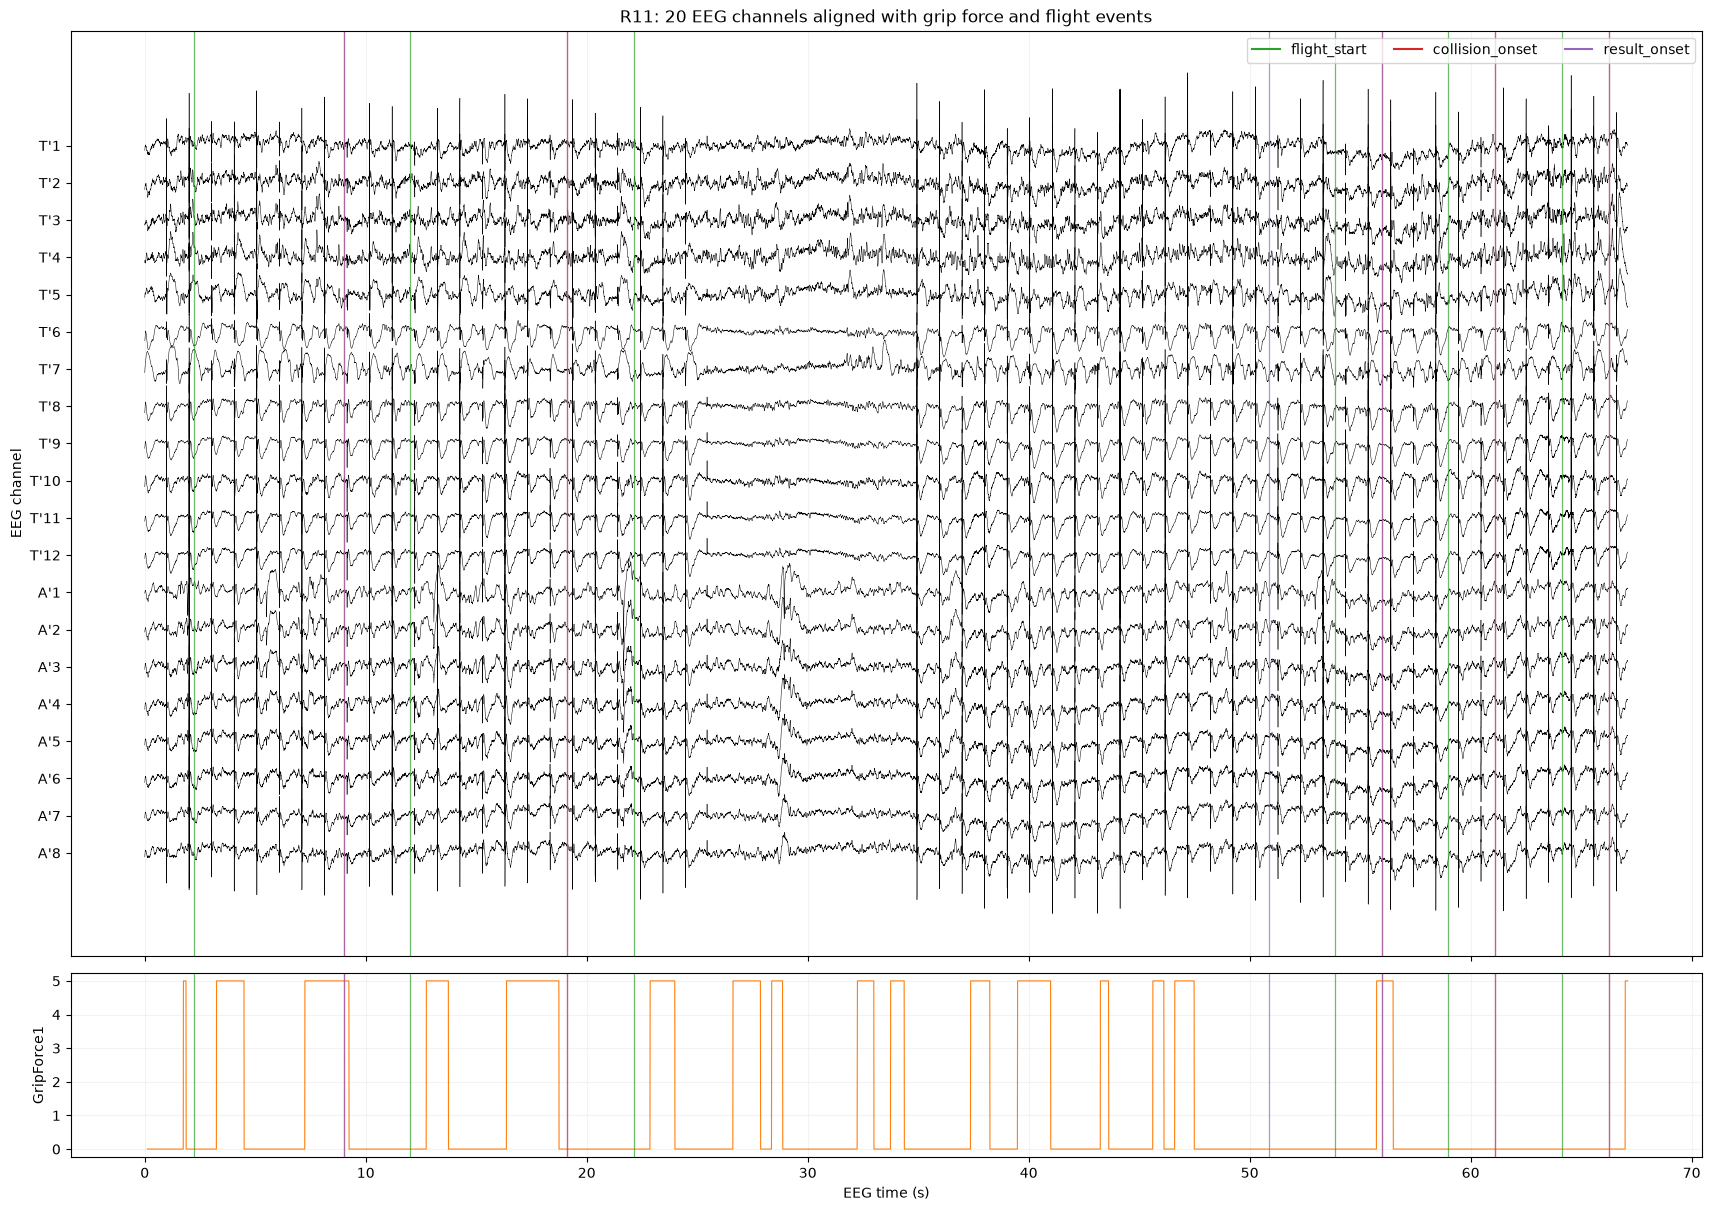

Displayed channels: ["T'1", "T'2", "T'3", "T'4", "T'5", "T'6", "T'7", "T'8", "T'9", "T'10", "T'11", "T'12", "A'1", "A'2", "A'3", "A'4", "A'5", "A'6", "A'7", "A'8"]


In [22]:
valid_indices = [i for i, name in enumerate(eeg.channel_names) if not name.startswith("EMPTY")]
channel_indices = valid_indices[:20]
channel_names = [eeg.channel_names[i] for i in channel_indices]

# 绘图降采样只减少屏幕上的点数，不影响事件对齐或后续 epoch 数据。
plot_step = 4
plot_indices = np.arange(0, eeg.samples, plot_step)
plot_time_s = plot_indices / eeg.sampling_rate
signals_20 = np.asarray(eeg.signals[plot_indices][:, channel_indices], dtype=float)
signals_20 -= np.nanmedian(signals_20, axis=0, keepdims=True)
channel_scale = np.nanstd(signals_20, axis=0, keepdims=True)
channel_scale[channel_scale == 0] = 1
stacked_signals = signals_20 / channel_scale + np.arange(20)[::-1] * 5

fig, (ax_eeg, ax_force) = plt.subplots(
    2, 1, figsize=(17, 12), sharex=True,
    gridspec_kw={"height_ratios": [5, 1]}, constrained_layout=True,
)
for channel_position in range(20):
    ax_eeg.plot(plot_time_s, stacked_signals[:, channel_position], lw=0.35, color="black")
ax_eeg.set_yticks(np.arange(20)[::-1] * 5, labels=channel_names)
ax_eeg.set_ylabel("EEG channel")
ax_eeg.set_title("R11: 20 EEG channels aligned with grip force and flight events")

ax_force.plot(plot_time_s, force_at_eeg_rate[plot_indices], color="tab:orange", lw=0.8)
ax_force.set(xlabel="EEG time (s)", ylabel="GripForce1")

colors = {
    "flight_start": "tab:green",
    "collision_onset": "tab:red",
    "result_onset": "tab:purple",
}
for event_name, color in colors.items():
    event_times = events.loc[events.event == event_name, "eeg_time_s"]
    for event_time in event_times:
        ax_eeg.axvline(event_time, color=color, alpha=0.7, lw=0.9)
        ax_force.axvline(event_time, color=color, alpha=0.7, lw=0.9)
    ax_eeg.plot([], [], color=color, label=event_name)

ax_eeg.legend(loc="upper right", ncol=3)
ax_eeg.grid(axis="x", alpha=0.15)
ax_force.grid(alpha=0.15)
plt.show()

print("Displayed channels:", channel_names)

## Extract event epochs

以每次 `flight_start` 为零点，截取前 1 秒、后 2 秒的 EEG 和握力。

In [23]:
pre_s, post_s = 1.0, 2.0
relative_time_s = np.arange(-int(pre_s * eeg.sampling_rate), int(post_s * eeg.sampling_rate)) / eeg.sampling_rate
flight_starts = events.query("event == 'flight_start'").eeg_sample.to_numpy(dtype=int)

eeg_epochs = np.stack([
    eeg.signals[start + int(relative_time_s[0] * eeg.sampling_rate):
                start + int(relative_time_s[-1] * eeg.sampling_rate) + 1, :]
    for start in flight_starts
])
force_epochs = np.stack([
    force_at_eeg_rate[start + int(relative_time_s[0] * eeg.sampling_rate):
                      start + int(relative_time_s[-1] * eeg.sampling_rate) + 1]
    for start in flight_starts
])

print("EEG epochs shape (trial, time, channel):", eeg_epochs.shape)
print("Force epochs shape (trial, time):", force_epochs.shape)

EEG epochs shape (trial, time, channel): (6, 6000, 272)
Force epochs shape (trial, time): (6, 6000)
